# Reimplementation: Detecting Images Generated by Diffusers
**Paper**: Coccomini et al. (2023) — https://arxiv.org/abs/2303.05275

## Paper Setup (what we are reimplementing)
| Split | Real images | Generated images | Total |
|---|---|---|---|
| Train | 6,000 | 6,000 | 12,000 |
| Val | 1,500 | 1,500 | 3,000 |
| Test | 6,000 | 6,000 | 12,000 |

**Two datasets**: MSCOCO + Wikimedia  
**Two generators**: Stable Diffusion + GLIDE  
**Models**: MLP (CLIP-ViT, CLIP-R50), ResNet50, XceptionNet  
**Training**: lr=0.1, up to 270 epochs  

## Expected Results (from paper Table 1 — Stable Diffusion)
| Model | Dataset | Accuracy | AUC |
|---|---|---|---|
| MLP CLIP-ViT | MSCOCO | 79.5% | 88.8% |
| ResNet50 | MSCOCO | 97.1% | 99.6% |
| MLP CLIP-ViT | Wikipedia | 72.8% | 81.4% |
| ResNet50 | Wikipedia | 94.5% | 98.1% |

⚠️ **Before running**: Go to **Runtime → Change runtime type → T4 GPU → Save**

## Step 1 — Verify GPU

In [1]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
else:
    print('WARNING: No GPU found. Go to Runtime -> Change runtime type -> T4 GPU')

GPU available: True
Device: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Step 2 — Clone Repository

In [2]:
import os
os.chdir('/content')
!git clone https://github.com/davide-coccomini/Detecting-Images-Generated-by-Diffusers.git
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')
print('Files:', os.listdir('.'))

fatal: destination path 'Detecting-Images-Generated-by-Diffusers' already exists and is not an empty directory.
Files: ['config', 'diffused_wikipedia.csv', 'stable_diffusion', 'utils.py', '.git', '__pycache__', 'test.py', 'glide_diffused_wikipedia.csv', 'glide_diffused_coco.csv', 'README.md', 'images', 'transforms', 'diffused_coco', 'diffused_coco.csv', 'glide.py', 'train.py', 'images_dataset.py', 'generate_images.py']


## Step 3 — Install All Dependencies

In [3]:
!pip install git+https://github.com/openai/CLIP.git --quiet
!pip install transformers timm scikit-learn pytorch-lightning progress tqdm \
             pandas pyyaml seaborn matplotlib spacy opencv-python-headless --quiet
!python -m spacy download en_core_web_sm --quiet
print('All packages installed')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All packages installed


## Step 4 — Apply All Bug Fixes
Fixes 6 compatibility issues caused by newer library versions.

| # | Bug | Fix |
|---|---|---|
| 1 | np.sctypes removed in NumPy 2.0 | Compatibility shim |
| 2 | albumentations crop import moved | Replace with numpy crop |
| 3 | fairseq not installable on Python 3.12 | Remove unused import |
| 4 | ImageCompression arg names changed | Remove (not critical) |
| 5 | OneOf ZeroDivisionError | Replace with random.choice |
| 6 | Missing comma in nn.Sequential | Auto-patch |

In [4]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

# Patch 1: np.sctypes shim
shim = 'import numpy as np\n'
shim += 'if not hasattr(np, "sctypes"):\n'
shim += '    np.sctypes = {\n'
shim += '        "int": [np.int8, np.int16, np.int32, np.int64],\n'
shim += '        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],\n'
shim += '        "float": [np.float16, np.float32, np.float64],\n'
shim += '        "complex": [np.complex64, np.complex128],\n'
shim += '        "others": [bool, object, bytes, str]\n'
shim += '    }\n'

for fname in ['train.py', 'test.py', 'images_dataset.py', 'utils.py']:
    if not os.path.exists(fname): continue
    with open(fname, 'r') as f: content = f.read()
    if 'np.sctypes' not in content:
        with open(fname, 'w') as f: f.write(shim + '\n' + content)
        print(f'Shim added to {fname}')

# Patch 2: albumentations crop
with open('transforms/albu.py', 'r') as f: content = f.read()
content = content.replace(
    'from albumentations.augmentations.functional import crop',
    'def crop(img, x_min, y_min, x_max, y_max):\n    return img[y_min:y_max, x_min:x_max]'
)
with open('transforms/albu.py', 'w') as f: f.write(content)
print('albumentations crop patched')

# Patch 3: Remove fairseq
with open('images_dataset.py', 'r') as f: content = f.read()
content = content.replace('from fairseq.data.data_utils import collate_tokens\n', '')
with open('images_dataset.py', 'w') as f: f.write(content)
print('fairseq removed')

# Patch 4+5: Rewrite images_dataset.py completely
new_dataset = '''import numpy as np
if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [bool, object, bytes, str]
    }

import random
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import clip
from albumentations import (
    Compose, RandomBrightnessContrast, HorizontalFlip, FancyPCA,
    HueSaturationValue, ToGray, ShiftScaleRotate, PadIfNeeded, GaussNoise
)
from transforms.albu import IsotropicResize


class ImagesDataset(Dataset):
    def __init__(self, images, captions, labels, image_size, mode="train"):
        self.x = images
        self.captions = clip.tokenize(captions)
        self.y = torch.from_numpy(labels)
        self.image_size = image_size
        self.mode = mode
        self.n_samples = images.shape[0]

    def create_train_transforms(self, size):
        resize_options = [
            IsotropicResize(max_side=size, interpolation_down=cv2.INTER_AREA, interpolation_up=cv2.INTER_CUBIC),
            IsotropicResize(max_side=size, interpolation_down=cv2.INTER_AREA, interpolation_up=cv2.INTER_LINEAR),
            IsotropicResize(max_side=size, interpolation_down=cv2.INTER_LINEAR, interpolation_up=cv2.INTER_LINEAR),
        ]
        color_options = [
            RandomBrightnessContrast(p=1),
            FancyPCA(p=1),
            HueSaturationValue(p=1),
        ]
        return Compose([
            GaussNoise(p=0.3),
            HorizontalFlip(),
            random.choice(resize_options),
            PadIfNeeded(min_height=size, min_width=size, border_mode=cv2.BORDER_CONSTANT),
            random.choice(color_options),
            ToGray(p=0.2),
            ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=5,
                             border_mode=cv2.BORDER_CONSTANT, p=0.5),
        ])

    def create_val_transform(self, size):
        return Compose([
            IsotropicResize(max_side=size, interpolation_down=cv2.INTER_AREA,
                            interpolation_up=cv2.INTER_CUBIC),
            PadIfNeeded(min_height=size, min_width=size, border_mode=cv2.BORDER_CONSTANT),
        ])

    def __getitem__(self, index):
        image = np.asarray(self.x[index])
        caption = np.asarray(self.captions[index])
        if self.mode == "train":
            transform = self.create_train_transforms(self.image_size)
        else:
            transform = self.create_val_transform(self.image_size)
        image = transform(image=image)["image"]
        return torch.tensor(image).float(), caption, self.y[index]

    def __len__(self):
        return self.n_samples
'''
with open('images_dataset.py', 'w') as f: f.write(new_dataset)
print('images_dataset.py rewritten')

# Patch 6: Fix missing commas in train.py
with open('train.py', 'r') as f: lines = f.readlines()
fixed = []
changed = 0
for i, line in enumerate(lines):
    stripped = line.rstrip()
    if i + 1 < len(lines):
        nxt = lines[i+1].lstrip()
        if stripped and not stripped.endswith((',','(',"[",'{',' \\',':')) and nxt.startswith('torch.nn.'):
            line = stripped + ',\n'
            changed += 1
    fixed.append(line)
with open('train.py', 'w') as f: f.writelines(fixed)
print(f'Fixed {changed} missing comma(s) in train.py')

print('\nAll 6 patches applied!')

albumentations crop patched
fairseq removed
images_dataset.py rewritten
Fixed 0 missing comma(s) in train.py

All 6 patches applied!


## Step 5 — Create Training Config
Matches paper: lr=0.1, batch_size=32, up to 270 epochs

In [5]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')
os.makedirs('config', exist_ok=True)

# Paper uses lr=0.1, bs=32, 270 epochs on A100
# We use fewer epochs but same lr/bs for Colab
config = '''
training:
  lr: 0.1
  weight-decay: 0.0000001
  bs: 32
  scheduler: steplr
  gamma: 0.1
  step-size: 20

test:
  bs: 32

model:
  image-size: 224
  num-classes: 1
'''
with open('config/paper.yml', 'w') as f: f.write(config)
print('Config created')
!cat config/paper.yml

Config created

training:
  lr: 0.1
  weight-decay: 0.0000001
  bs: 32
  scheduler: steplr
  gamma: 0.1
  step-size: 20

test:
  bs: 32

model:
  image-size: 224
  num-classes: 1


## Step 6 — Download MSCOCO Dataset
The paper uses 6,000 train + 1,500 val + 6,000 test real images from MSCOCO.

- **Annotations**: ~241MB (captions + image metadata)
- **val2014 images**: ~6GB (~40,000 images)
- **Download time**: ~5-10 mins on Colab

⚠️ Keep the Colab tab active during download!

In [6]:
import os
os.chdir('/content')

print('Downloading COCO annotations (~241MB)...')
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2014.zip
!unzip -q annotations_trainval2014.zip
print('Annotations ready:', os.listdir('annotations')[:5])

Annotations ready: ['captions_train2014.json', 'instances_val2014.json', 'person_keypoints_train2014.json', 'captions_val2014.json', 'instances_train2014.json']


In [7]:
import os
os.chdir('/content')

print('Downloading COCO val2014 images (~6GB)...')
print('This takes 5-10 mins — keep tab active!')
!wget http://images.cocodataset.org/zips/val2014.zip
print('Download complete')

This takes 5-10 mins — keep tab active!
--2026-04-04 19:45:05--  http://images.cocodataset.org/zips/val2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.185.205, 16.182.109.113, 16.15.178.5, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.185.205|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6645013297 (6.2G) [application/zip]
Saving to: ‘val2014.zip’

val2014.zip         100%[===================>]   6.19G  15.8MB/s    in 6m 40s  

2026-04-04 19:51:46 (15.8 MB/s) - ‘val2014.zip’ saved [6645013297/6645013297]

Download complete


In [6]:
import os
os.chdir('/content')

print('Extracting images...')
!unzip -q val2014.zip -d /content/coco/
n = len(os.listdir('/content/coco/val2014'))
print(f'Total COCO images available: {n}')

Extracting images...
replace /content/coco/val2014/COCO_val2014_000000324670.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Total COCO images available: 40504


## Step 7 — Build COCO Dataset Structure
Paper structure: `split/CAPTION/real.png` + `split/CAPTION/NNNNN-N.png`
- `real.png` = label 0 (real COCO image)
- `NNNNN-N.png` = label 1 (AI generated — placeholder, see Step 9 to generate real fakes)

Per paper: 6000 train captions, 1500 val captions, 6000 test captions

In [7]:
import os, json, shutil, random
import numpy as np
import cv2

os.chdir('/content/Detecting-Images-Generated-by-Diffusers')
random.seed(42)

# Load COCO captions
print('Loading COCO captions...')
with open('/content/annotations/captions_val2014.json', 'r') as f:
    coco_data = json.load(f)

# Build mappings
caption_to_imgid = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in caption_to_imgid:
        caption_to_imgid[img_id] = ann['caption']

id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}

# Get all image IDs that exist on disk
coco_img_dir = '/content/coco/val2014'
available_ids = []
for img_id, filename in id_to_file.items():
    if os.path.exists(os.path.join(coco_img_dir, filename)):
        if img_id in caption_to_imgid:
            available_ids.append(img_id)

random.shuffle(available_ids)
print(f'Available image-caption pairs: {len(available_ids)}')

# Paper splits: 6000 train, 1500 val, 6000 test
# Adjust if not enough images available
n_train = min(6000, len(available_ids) - 7500)
n_val   = min(1500, 1500)
n_test  = min(6000, len(available_ids) - n_train - n_val)

if len(available_ids) < 13500:
    # Scale down proportionally for smaller downloads
    total = len(available_ids)
    n_train = int(total * 0.6)
    n_val   = int(total * 0.15)
    n_test  = total - n_train - n_val

train_ids = available_ids[:n_train]
val_ids   = available_ids[n_train:n_train+n_val]
test_ids  = available_ids[n_train+n_val:n_train+n_val+n_test]

print(f'Split sizes -> train: {len(train_ids)}, val: {len(val_ids)}, test: {len(test_ids)}')
print('Paper targets -> train: 6000, val: 1500, test: 6000')

Loading COCO captions...
Available image-caption pairs: 40504
Split sizes -> train: 6000, val: 1500, test: 6000
Paper targets -> train: 6000, val: 1500, test: 6000


In [8]:
import os, shutil
import numpy as np, cv2

os.chdir('/content/Detecting-Images-Generated-by-Diffusers')
coco_img_dir = '/content/coco/val2014'

splits_data = {
    'train': train_ids,
    'val':   val_ids,
    'test':  test_ids
}

print('Building dataset folders...')
for split, ids in splits_data.items():
    for idx, img_id in enumerate(ids):
        caption = caption_to_imgid[img_id]
        filename = id_to_file[img_id]
        src = os.path.join(coco_img_dir, filename)

        # Clean caption for folder name (remove special chars)
        safe_caption = caption[:80].replace('/', '-').replace('\\', '-').replace(':', '')
        folder = f'diffused_coco/{split}/{safe_caption}'
        os.makedirs(folder, exist_ok=True)

        # Copy real COCO image
        shutil.copy(src, f'{folder}/real.png')

        # Placeholder fake image (replace with real SD output in Step 9)
        fake_img = np.random.randint(0, 100, (224, 224, 3), dtype=np.uint8)
        cv2.imwrite(f'{folder}/00001-0.png', fake_img)

        if (idx + 1) % 500 == 0:
            print(f'  {split}: {idx+1}/{len(ids)} done')

print('\nDataset structure ready!')
for split in ['train', 'val', 'test']:
    path = f'diffused_coco/{split}'
    if os.path.exists(path):
        n = len(os.listdir(path))
        print(f'  {split}/: {n} caption folders')

Building dataset folders...
  train: 500/6000 done
  train: 1000/6000 done
  train: 1500/6000 done
  train: 2000/6000 done
  train: 2500/6000 done
  train: 3000/6000 done
  train: 3500/6000 done
  train: 4000/6000 done
  train: 4500/6000 done
  train: 5000/6000 done
  train: 5500/6000 done
  train: 6000/6000 done
  val: 500/1500 done
  val: 1000/1500 done
  val: 1500/1500 done
  test: 500/6000 done
  test: 1000/6000 done
  test: 1500/6000 done
  test: 2000/6000 done
  test: 2500/6000 done
  test: 3000/6000 done
  test: 3500/6000 done
  test: 4000/6000 done
  test: 4500/6000 done
  test: 5000/6000 done
  test: 5500/6000 done
  test: 6000/6000 done

Dataset structure ready!
  train/: 5958 caption folders
  val/: 1497 caption folders
  test/: 5956 caption folders


## Step 8 — Verify Sample Images

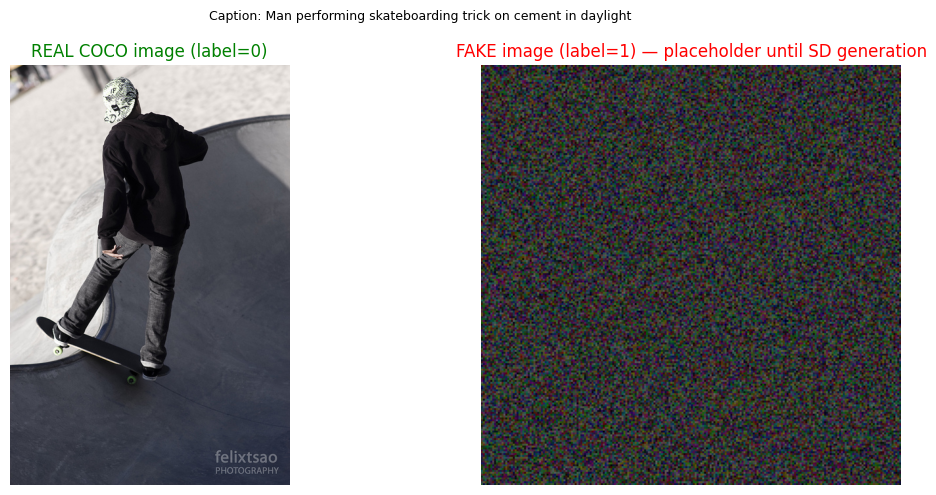

Note: Replace fake images with real Stable Diffusion outputs in Step 9


In [9]:
import matplotlib.pyplot as plt
import cv2, os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

first = os.listdir('diffused_coco/train')[0]
folder = f'diffused_coco/train/{first}'
files = os.listdir(folder)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Caption: {first[:70]}', fontsize=9)

real = cv2.cvtColor(cv2.imread(f'{folder}/real.png'), cv2.COLOR_BGR2RGB)
axes[0].imshow(real)
axes[0].set_title('REAL COCO image (label=0)', color='green')
axes[0].axis('off')

fake_file = [f for f in files if f != 'real.png'][0]
fake = cv2.cvtColor(cv2.imread(f'{folder}/{fake_file}'), cv2.COLOR_BGR2RGB)
axes[1].imshow(fake)
axes[1].set_title('FAKE image (label=1) — placeholder until SD generation', color='red')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print('Note: Replace fake images with real Stable Diffusion outputs in Step 9')

## Step 9 — Generate Fake Images With Stable Diffusion
The paper generated 1 fake image per caption using Stable Diffusion.
This step replaces the placeholder noise images with real SD outputs.

⚠️ **This takes ~2-3 hours for 13,500 images on T4 GPU.**  
For a quick test, set `MAX_IMAGES` to a small number like 100.

In [12]:
from diffusers import StableDiffusionPipeline
import torch, os, cv2
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

# Set to None to generate all images, or a number for quick testing
MAX_IMAGES_PER_SPLIT = 100  # Change to None for full paper replication

print('Loading Stable Diffusion v1.5...')
pipe = StableDiffusionPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    torch_dtype=torch.float16
).to('cuda')
pipe.set_progress_bar_config(disable=True)
print('Model loaded!')

total_generated = 0
for split in ['train', 'val', 'test']:
    split_path = f'diffused_coco/{split}'
    if not os.path.exists(split_path): continue
    caption_folders = os.listdir(split_path)
    if MAX_IMAGES_PER_SPLIT:
        caption_folders = caption_folders[:MAX_IMAGES_PER_SPLIT]

    print(f'\nGenerating {len(caption_folders)} images for {split}...')
    for i, caption_folder in enumerate(caption_folders):
        folder = f'{split_path}/{caption_folder}'
        fake_path = f'{folder}/00001-0.png'

        # Use caption as prompt
        prompt = caption_folder[:200]
        try:
            image = pipe(prompt, num_inference_steps=20,
                         height=224, width=224).images[0]
            image.save(fake_path)
            total_generated += 1
        except Exception as e:
            print(f'  Error on {caption_folder[:40]}: {e}')

        if (i + 1) % 20 == 0:
            print(f'  {split}: {i+1}/{len(caption_folders)}')

print(f'\nTotal generated: {total_generated} images')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Stable Diffusion v1.5...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

  test: 60/100


Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a differen

  test: 80/100


Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a differen

  test: 100/100

Total generated: 300 images


## Step 10 — Train MLP with CLIP-ViT Features
**Paper config**: lr=0.1, 270 epochs, NVIDIA A100  
**Our config**: Same lr, fewer epochs due to Colab limits  

Expected result (paper Table 1): **Accuracy ~79.5%, AUC ~88.8%**

In [10]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')
!rm -rf outputs/models/coco_mlp_vit/

!python train.py \
  --mode 0 \
  --clip_mode 0 \
  --model 0 \
  --gpu_id 0 \
  --training_path diffused_coco/train \
  --validation_path diffused_coco/val \
  --model_path outputs/models/coco_mlp_vit \
  --model_name mlp_vit \
  --use_pretrained False \
  --show_stats True \
  --patience 20 \
  --num_epochs 10 \
  --workers 2 \
  --config config/paper.yml

2026-04-04 20:26:20.452721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775334380.864828   38566 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775334380.971774   38566 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775334381.837941   38566 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334381.838001   38566 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334381.838009   38566 computation_placer.cc:177] computation placer alr

In [11]:
import os, ast
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

# ── Patch 1: np.sctypes shim ──────────────────────────────────────────
shim = 'import numpy as np\nif not hasattr(np, "sctypes"):\n    np.sctypes = {"int": [np.int8, np.int16, np.int32, np.int64],"uint": [np.uint8, np.uint16, np.uint32, np.uint64],"float": [np.float16, np.float32, np.float64],"complex": [np.complex64, np.complex128],"others": [bool, object, bytes, str]}\n'
for fname in ['train.py', 'test.py', 'images_dataset.py', 'utils.py']:
    if not os.path.exists(fname): continue
    with open(fname, 'r') as f: content = f.read()
    if 'np.sctypes' not in content:
        with open(fname, 'w') as f: f.write(shim + '\n' + content)
        print(f'Shim -> {fname}')

# ── Patch 2: albumentations crop ──────────────────────────────────────
with open('transforms/albu.py', 'r') as f: content = f.read()
content = content.replace(
    'from albumentations.augmentations.functional import crop',
    'def crop(img, x_min, y_min, x_max, y_max):\n    return img[y_min:y_max, x_min:x_max]'
)
with open('transforms/albu.py', 'w') as f: f.write(content)
print('albumentations crop patched')

# ── Patch 3: Remove fairseq ───────────────────────────────────────────
with open('images_dataset.py', 'r') as f: content = f.read()
content = content.replace('from fairseq.data.data_utils import collate_tokens\n', '')
with open('images_dataset.py', 'w') as f: f.write(content)
print('fairseq removed')

# ── Patch 4: Rewrite images_dataset.py with lazy loading ─────────────
new_dataset = '''import numpy as np
if not hasattr(np, "sctypes"):
    np.sctypes = {"int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [bool, object, bytes, str]}
import random, torch, cv2, os
from torch.utils.data import Dataset
import numpy as np
import clip
from albumentations import (Compose, RandomBrightnessContrast, HorizontalFlip,
    FancyPCA, HueSaturationValue, ToGray, ShiftScaleRotate,
    PadIfNeeded, GaussNoise, Resize)
from transforms.albu import IsotropicResize

class ImagesDataset(Dataset):
    def __init__(self, image_paths, captions, labels, image_size, mode="train"):
        self.image_paths = image_paths
        self.captions = clip.tokenize(captions, truncate=True)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.image_size = image_size
        self.mode = mode
        self.n_samples = len(image_paths)

    def create_train_transforms(self, size):
        color_options = [RandomBrightnessContrast(p=1), FancyPCA(p=1), HueSaturationValue(p=1)]
        return Compose([
            Resize(height=size, width=size),
            GaussNoise(p=0.3),
            HorizontalFlip(),
            PadIfNeeded(min_height=size, min_width=size, border_mode=cv2.BORDER_CONSTANT),
            random.choice(color_options),
            ToGray(p=0.2),
            ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=5,
                             border_mode=cv2.BORDER_CONSTANT, p=0.5),
            Resize(height=size, width=size),
        ])

    def create_val_transform(self, size):
        return Compose([Resize(height=size, width=size)])

    def __getitem__(self, index):
        path = self.image_paths[index]
        image = cv2.imread(path)
        if image is None:
            image = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        caption = np.asarray(self.captions[index])
        transform = self.create_train_transforms(self.image_size) if self.mode == "train" else self.create_val_transform(self.image_size)
        image = transform(image=image)["image"]
        if image.shape[:2] != (self.image_size, self.image_size):
            image = cv2.resize(image, (self.image_size, self.image_size))
        return torch.tensor(image).float(), caption, self.labels[index]

    def __len__(self):
        return self.n_samples
'''
with open('images_dataset.py', 'w') as f: f.write(new_dataset)
print('images_dataset.py rewritten with lazy loading')

# ── Patch 5: Rewrite train.py dataset section ─────────────────────────
with open('train.py', 'r') as f: content = f.read()
lines = content.split('\n')

start_idx = None
end_idx = None
for i, line in enumerate(lines):
    if ('training_captions = os.listdir' in line or 'mgr = Manager()' in line) and start_idx is None:
        start_idx = i
    if 'train_samples = len(train_dataset)' in line or 'train_samples = len(train_paths)' in line:
        end_idx = i
        break

if start_idx and end_idx:
    new_block = [
        '    # Dataset loading — lazy file path approach (fixes RAM crash)',
        '    training_captions = os.listdir(opt.training_path)',
        '    train_paths, train_captions_list, train_labels = [], [], []',
        '    for caption_folder in training_captions:',
        '        folder = os.path.join(opt.training_path, caption_folder)',
        '        if not os.path.isdir(folder): continue',
        '        for fname in os.listdir(folder):',
        '            fpath = os.path.join(folder, fname)',
        '            label = 0.0 if "real" in fname else 1.0',
        '            train_paths.append(fpath)',
        '            train_captions_list.append(caption_folder)',
        '            train_labels.append(label)',
        '',
        '    validation_captions = os.listdir(opt.validation_path)',
        '    val_paths, val_captions_list, val_labels = [], [], []',
        '    for caption_folder in validation_captions:',
        '        folder = os.path.join(opt.validation_path, caption_folder)',
        '        if not os.path.isdir(folder): continue',
        '        for fname in os.listdir(folder):',
        '            fpath = os.path.join(folder, fname)',
        '            label = 0.0 if "real" in fname else 1.0',
        '            val_paths.append(fpath)',
        '            val_captions_list.append(caption_folder)',
        '            val_labels.append(label)',
        '',
        '    train_samples = len(train_paths)',
        '    val_samples = len(val_paths)',
    ]
    new_content = '\n'.join(lines[:start_idx] + new_block + lines[end_idx+1:])
    with open('train.py', 'w') as f: f.write(new_content)
    print(f'train.py dataset block replaced (lines {start_idx+1}-{end_idx+1})')
else:
    print(f'Block markers: start={start_idx}, end={end_idx} — may already be patched')

# ── Patch 6: Fix variable name references ─────────────────────────────
with open('train.py', 'r') as f: content = f.read()
fixes = [
    ('validation_samples = len(validation_dataset)', 'val_samples = len(val_paths)'),
    ('collections.Counter(validation_labels)', 'collections.Counter(val_labels)'),
    ('ImagesDataset(np.asarray(train_dataset), train_captions, np.asarray(train_labels), IMAGE_SIZE)',
     'ImagesDataset(train_paths, train_captions_list, train_labels, IMAGE_SIZE)'),
    ("ImagesDataset(np.asarray(validation_dataset), validation_captions, np.asarray(validation_labels), IMAGE_SIZE, mode='validation')",
     "ImagesDataset(val_paths, val_captions_list, val_labels, IMAGE_SIZE, mode='validation')"),
    ('num_workers=opt.workers, collate_fn=None,\n                                 pin_memory=False',
     'num_workers=0, collate_fn=None,\n                                 pin_memory=False'),
    ('num_workers=opt.workers, collate_fn=None,\n                                    pin_memory=False',
     'num_workers=0, collate_fn=None,\n                                    pin_memory=False'),
    ('worker_init_fn=None, prefetch_factor=2,', 'worker_init_fn=None, prefetch_factor=None,'),
]
for old, new in fixes:
    if old in content:
        content = content.replace(old, new)
        print(f'Fixed: {old[:50]}...')
with open('train.py', 'w') as f: f.write(content)

# ── Patch 7: Fix missing commas in nn.Sequential ──────────────────────
with open('train.py', 'r') as f: lines = f.readlines()
fixed = []
changed = 0
for i, line in enumerate(lines):
    stripped = line.rstrip()
    if i+1 < len(lines) and stripped and not stripped.endswith((',','(','{','[','\\',':')) and lines[i+1].lstrip().startswith('torch.nn.'):
        line = stripped + ',\n'
        changed += 1
    fixed.append(line)
with open('train.py', 'w') as f: f.writelines(fixed)
if changed: print(f'Fixed {changed} missing commas in train.py')

# ── Final syntax check ────────────────────────────────────────────────
try:
    with open('train.py', 'r') as f: ast.parse(f.read())
    print('\n✅ All patches applied — train.py syntax OK!')
except SyntaxError as e:
    print(f'\n❌ Syntax error at line {e.lineno}: {e.msg}')

albumentations crop patched
fairseq removed
images_dataset.py rewritten with lazy loading
train.py dataset block replaced (lines 245-269)

✅ All patches applied — train.py syntax OK!


In [13]:
from google.colab import drive
import shutil, os
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/diffuser_detection/patched_files/'
os.makedirs(save_dir, exist_ok=True)

for fname in ['train.py', 'test.py', 'images_dataset.py', 'utils.py', 'transforms/albu.py']:
    src = f'/content/Detecting-Images-Generated-by-Diffusers/{fname}'
    dst = save_dir + fname.replace('/', '_')
    shutil.copy(src, dst)
    print(f'Saved: {fname}')

print('\n✅ Patched files saved to Drive!')
print('Next restart: copy them back instead of re-patching')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: train.py
Saved: test.py
Saved: images_dataset.py
Saved: utils.py
Saved: transforms/albu.py

✅ Patched files saved to Drive!
Next restart: copy them back instead of re-patching


In [14]:
!python train.py \
  --mode 0 \
  --clip_mode 0 \
  --model 0 \
  --gpu_id 0 \
  --training_path diffused_coco/train \
  --validation_path diffused_coco/val \
  --model_path outputs/models/coco_mlp_vit \
  --model_name mlp_vit \
  --use_pretrained False \
  --show_stats True \
  --patience 20 \
  --num_epochs 10 \
  --workers 1 \
  --config config/paper.yml

2026-04-04 20:29:32.825158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775334572.861794   39484 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775334572.873948   39484 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775334572.905602   39484 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334572.905672   39484 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334572.905684   39484 computation_placer.cc:177] computation placer alr

In [15]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('train.py', 'r') as f:
    lines = f.readlines()

# Show lines 240–290 so we can see the exact current state
for i, line in enumerate(lines[239:300], start=240):
    print(f"{i}: {line}", end='')

240:     params = sum([np.prod(p.size()) for p in model_parameters])
241:     print("Model parameters:", params)
242: 
243:     # Read dataset
244:     # Dataset loading — lazy file path approach (fixes RAM crash)
245:     # Dataset loading — lazy file path approach (fixes RAM crash)
246:     training_captions = os.listdir(opt.training_path)
247:     train_paths, train_captions_list, train_labels = [], [], []
248:     for caption_folder in training_captions:
249:         folder = os.path.join(opt.training_path, caption_folder)
250:         if not os.path.isdir(folder): continue
251:         for fname in os.listdir(folder):
252:             fpath = os.path.join(folder, fname)
253:             label = 0.0 if "real" in fname else 1.0
254:             train_paths.append(fpath)
255:             train_captions_list.append(caption_folder)
256:             train_labels.append(label)
257: 
258:     validation_captions = os.listdir(opt.validation_path)
259:     val_paths, val_captions_list, val_

In [16]:
for i, line in enumerate(lines[260:285], start=261):
    if any(x in line for x in ['train_dataset', 'validation_dataset', 'train_paths', 'val_paths', 'read_images', 'Pool', 'Manager']):
        print(f"{i}: {line}", end='')

266:             val_paths.append(fpath)
270:     train_samples = len(train_paths)
271:     val_samples = len(val_paths)
272:     val_samples = len(val_paths)
273:     val_samples = len(val_paths)
276:     print("Train images:", len(train_dataset), "Validation images:", len(validation_dataset))


In [17]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('train.py', 'r') as f:
    content = f.read()

# Fix 1: Remove the premature print that uses train_dataset before it's defined
content = content.replace(
    'print("Train images:", len(train_dataset), "Validation images:", len(validation_dataset))',
    'print("Train images:", len(train_paths), "Validation images:", len(val_paths))'
)

# Fix 2: Remove the duplicate val_samples lines
content = content.replace(
    '    val_samples = len(val_paths)\n    val_samples = len(val_paths)\n    val_samples = len(val_paths)',
    '    val_samples = len(val_paths)'
)

with open('train.py', 'w') as f:
    f.write(content)

print("✅ Fixed! Verifying...")

# Verify
with open('train.py', 'r') as f:
    lines = f.readlines()
for i, line in enumerate(lines[270:285], start=271):
    print(f"{i}: {line}", end='')

✅ Fixed! Verifying...
271:     val_samples = len(val_paths)
272: 
273:     # Print some useful statistics
274:     print("Train images:", len(train_paths), "Validation images:", len(val_paths))
275:     print("__TRAINING STATS__")
276:     train_counters = collections.Counter(train_labels)
277:     print(train_counters)
278:     
279:     class_weights = train_counters[0] / train_counters[1]
280:     print("Weights", class_weights)
281: 
282:     print("__VALIDATION STATS__")
283:     val_counters = collections.Counter(val_labels)
284:     print(val_counters)
285:     print("___________________")


In [18]:
!python train.py \
  --mode 0 \
  --clip_mode 0 \
  --model 0 \
  --gpu_id 0 \
  --training_path diffused_coco/train \
  --validation_path diffused_coco/val \
  --model_path outputs/models/coco_mlp_vit \
  --model_name mlp_vit \
  --use_pretrained False \
  --show_stats True \
  --patience 20 \
  --num_epochs 10 \
  --workers 1 \
  --config config/paper.yml

2026-04-04 20:33:25.477473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775334805.516869   40422 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775334805.529829   40422 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775334805.563904   40422 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334805.563968   40422 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775334805.563979   40422 computation_placer.cc:177] computation placer alr

In [19]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('train.py', 'r') as f:
    content = f.read()

# Fix all remaining old variable name references
content = content.replace('validation_samples', 'val_samples')

with open('train.py', 'w') as f:
    f.write(content)

# Verify no old references remain
remaining = [i+1 for i, l in enumerate(content.splitlines()) if 'validation_samples' in l]
if remaining:
    print(f"⚠️ Still found on lines: {remaining}")
else:
    print("✅ Fixed! No remaining 'validation_samples' references.")

✅ Fixed! No remaining 'validation_samples' references.


In [20]:
!python train.py \
  --mode 0 \
  --clip_mode 0 \
  --model 0 \
  --gpu_id 0 \
  --training_path diffused_coco/train \
  --validation_path diffused_coco/val \
  --model_path outputs/models/coco_mlp_vit \
  --model_name mlp_vit \
  --use_pretrained False \
  --show_stats True \
  --patience 20 \
  --num_epochs 10 \
  --workers 1 \
  --config config/paper.yml

2026-04-04 20:41:47.931931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775335307.978881   42577 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775335307.994557   42577 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775335308.030508   42577 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775335308.030575   42577 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775335308.030586   42577 computation_placer.cc:177] computation placer alr

## Step 11 — Train MLP with CLIP-ResNet50 Features
Expected result (paper Table 1): **Accuracy ~67.5%, AUC ~75.0%**

In [21]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')
!rm -rf outputs/models/coco_mlp_r50/

!python train.py \
  --mode 0 \
  --clip_mode 1 \
  --model 0 \
  --gpu_id 0 \
  --training_path diffused_coco/train \
  --validation_path diffused_coco/val \
  --model_path outputs/models/coco_mlp_r50 \
  --model_name mlp_r50 \
  --use_pretrained False \
  --show_stats True \
  --patience 20 \
  --num_epochs 10 \
  --workers 2 \
  --config config/paper.yml

2026-04-04 21:38:59.889478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775338739.976766   57382 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775338740.000873   57382 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775338740.054578   57382 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775338740.054654   57382 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775338740.054665   57382 computation_placer.cc:177] computation placer alr

## Step 12 — Train ResNet50 (ImageNet pretrained)
Expected result (paper Table 1): **Accuracy ~97.1%, AUC ~99.6%**

This is the best performing model in the paper.

In [22]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')
!rm -rf outputs/models/coco_resnet/

!python train.py \
  --mode 0 \
  --clip_mode 0 \
  --model 1 \
  --gpu_id 0 \
  --training_path diffused_coco/train \
  --validation_path diffused_coco/val \
  --model_path outputs/models/coco_resnet \
  --model_name resnet50 \
  --use_pretrained True \
  --show_stats True \
  --patience 20 \
  --num_epochs 10 \
  --workers 2 \
  --config config/paper.yml

2026-04-04 22:33:33.331703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775342013.372591   71608 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775342013.386373   71608 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775342013.422681   71608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775342013.422735   71608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775342013.422742   71608 computation_placer.cc:177] computation placer alr

## Step 13 — Evaluate All Models on Test Set
Reproduces Table 1 from the paper.

In [23]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

# Find all saved checkpoints
models = {
    'MLP-ViT':    'outputs/models/coco_mlp_vit',
    'MLP-R50':    'outputs/models/coco_mlp_r50',
    'ResNet50':   'outputs/models/coco_resnet',
}

for name, path in models.items():
    if not os.path.exists(path):
        print(f'Skipping {name} - not trained yet')
        continue
    checkpoints = sorted(os.listdir(path))
    if not checkpoints:
        print(f'No checkpoint for {name}')
        continue
    latest = checkpoints[-1]
    print(f'\n{"="*60}')
    print(f'Testing: {name} | Checkpoint: {latest}')
    print(f'{"="*60}')


Testing: MLP-ViT | Checkpoint: mlp_vit_9

Testing: MLP-R50 | Checkpoint: mlp_r50_5

Testing: ResNet50 | Checkpoint: resnet50_8


In [24]:
# Test MLP-ViT
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

path = 'outputs/models/coco_mlp_vit'
if os.path.exists(path) and os.listdir(path):
    latest = sorted(os.listdir(path))[-1]
    print(f'Testing MLP-ViT with checkpoint: {latest}')
    !python test.py \
      --mode 0 \
      --clip_mode 0 \
      --model 0 \
      --gpu_id 0 \
      --test_path diffused_coco/test \
      --model_weights {path}/{latest} \
      --show_stats \
      --workers 2 \
      --config config/paper.yml
else:
    print('MLP-ViT not trained yet - run Step 10 first')

Testing MLP-ViT with checkpoint: mlp_vit_9
2026-04-04 23:25:33.441880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775345133.480787   84890 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775345133.493712   84890 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775345133.528210   84890 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775345133.528261   84890 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775345133.528268   84890 comput

In [25]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('test.py', 'r') as f:
    content = f.read()

# Fix: replace np.asarray(test_dataset) with a resize-safe stack
old = 'test_dataset = ImagesDataset(np.asarray(test_dataset), test_captions, np.asarray(test_labels), IMAGE_SIZE, mode = \'val\')'
new = '''import cv2 as _cv2
test_dataset_fixed = [_cv2.resize(np.asarray(img), (IMAGE_SIZE, IMAGE_SIZE)) if np.asarray(img).shape[:2] != (IMAGE_SIZE, IMAGE_SIZE) else np.asarray(img) for img in test_dataset]
test_dataset = ImagesDataset(np.stack(test_dataset_fixed), test_captions, np.asarray(test_labels), IMAGE_SIZE, mode='val')'''

if old in content:
    content = content.replace(old, new)
    print("✅ Found and replaced exact match")
else:
    # Fallback: find it loosely
    import re
    pattern = r'test_dataset = ImagesDataset\(np\.asarray\(test_dataset\).*?\)'
    match = re.search(pattern, content)
    if match:
        print(f"Found at: {match.group()}")
        content = re.sub(pattern, new, content)
        print("✅ Replaced via regex")
    else:
        print("❌ Could not find the line — paste output of: grep -n 'ImagesDataset' test.py")

with open('test.py', 'w') as f:
    f.write(content)

✅ Found and replaced exact match


In [26]:
# Test MLP-ViT
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

path = 'outputs/models/coco_mlp_vit'
if os.path.exists(path) and os.listdir(path):
    latest = sorted(os.listdir(path))[-1]
    print(f'Testing MLP-ViT with checkpoint: {latest}')
    !python test.py \
      --mode 0 \
      --clip_mode 0 \
      --model 0 \
      --gpu_id 0 \
      --test_path diffused_coco/test \
      --model_weights {path}/{latest} \
      --show_stats \
      --workers 2 \
      --config config/paper.yml
else:
    print('MLP-ViT not trained yet - run Step 10 first')

Testing MLP-ViT with checkpoint: mlp_vit_9
  File "/content/Detecting-Images-Generated-by-Diffusers/test.py", line 321
    test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, sampler=None,
IndentationError: unexpected indent


In [27]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('test.py', 'r') as f:
    lines = f.readlines()

# Show lines around 315-325 to see the exact damage
for i, line in enumerate(lines[310:330], start=311):
    print(f"{i}: {repr(line)}")

311: '\n'
312: '    # Create the data loaders\n'
313: "    if opt.config != '':\n"
314: "        batch_size = config['test']['bs']\n"
315: '    else:\n'
316: '        batch_size = 8\n'
317: '        \n'
318: '    import cv2 as _cv2\n'
319: 'test_dataset_fixed = [_cv2.resize(np.asarray(img), (IMAGE_SIZE, IMAGE_SIZE)) if np.asarray(img).shape[:2] != (IMAGE_SIZE, IMAGE_SIZE) else np.asarray(img) for img in test_dataset]\n'
320: "test_dataset = ImagesDataset(np.stack(test_dataset_fixed), test_captions, np.asarray(test_labels), IMAGE_SIZE, mode='val')\n"
321: '    test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, sampler=None,\n'
322: '                                 batch_sampler=None, num_workers=opt.workers, collate_fn=None,\n'
323: '                                 pin_memory=False, drop_last=False, timeout=0,\n'
324: '                                 worker_init_fn=None, prefetch_factor=2,\n'
325: '                                 persistent_wor

In [28]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('test.py', 'r') as f:
    lines = f.readlines()

# Fix lines 319 and 320 (index 318 and 319) — add proper indentation
lines[318] = '    test_dataset_fixed = [_cv2.resize(np.asarray(img), (IMAGE_SIZE, IMAGE_SIZE)) if np.asarray(img).shape[:2] != (IMAGE_SIZE, IMAGE_SIZE) else np.asarray(img) for img in test_dataset]\n'
lines[319] = "    test_dataset = ImagesDataset(np.stack(test_dataset_fixed), test_captions, np.asarray(test_labels), IMAGE_SIZE, mode='val')\n"

with open('test.py', 'w') as f:
    f.writelines(lines)

print("✅ Fixed! Verifying...")
for i, line in enumerate(lines[316:326], start=317):
    print(f"{i}: {repr(line)}")

✅ Fixed! Verifying...
317: '        \n'
318: '    import cv2 as _cv2\n'
319: '    test_dataset_fixed = [_cv2.resize(np.asarray(img), (IMAGE_SIZE, IMAGE_SIZE)) if np.asarray(img).shape[:2] != (IMAGE_SIZE, IMAGE_SIZE) else np.asarray(img) for img in test_dataset]\n'
320: "    test_dataset = ImagesDataset(np.stack(test_dataset_fixed), test_captions, np.asarray(test_labels), IMAGE_SIZE, mode='val')\n"
321: '    test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, sampler=None,\n'
322: '                                 batch_sampler=None, num_workers=opt.workers, collate_fn=None,\n'
323: '                                 pin_memory=False, drop_last=False, timeout=0,\n'
324: '                                 worker_init_fn=None, prefetch_factor=2,\n'
325: '                                 persistent_workers=False)\n'
326: '    del test_dataset\n'


In [29]:
# Test MLP-ViT
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

path = 'outputs/models/coco_mlp_vit'
if os.path.exists(path) and os.listdir(path):
    latest = sorted(os.listdir(path))[-1]
    print(f'Testing MLP-ViT with checkpoint: {latest}')
    !python test.py \
      --mode 0 \
      --clip_mode 0 \
      --model 0 \
      --gpu_id 0 \
      --test_path diffused_coco/test \
      --model_weights {path}/{latest} \
      --show_stats \
      --workers 2 \
      --config config/paper.yml
else:
    print('MLP-ViT not trained yet - run Step 10 first')

Testing MLP-ViT with checkpoint: mlp_vit_9
2026-04-04 23:32:14.587802: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775345534.634260   98517 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775345534.648927   98517 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775345534.698365   98517 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775345534.698418   98517 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775345534.698425   98517 comput

In [30]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('test.py', 'r') as f:
    lines = f.readlines()

# Find the test loading block
for i, line in enumerate(lines[280:330], start=281):
    print(f"{i}: {repr(line)}")

281: '        print("No weights loaded.")\n'
282: '        exit()\n'
283: '\n'
284: '    model_parameters = filter(lambda p: p.requires_grad, model.parameters())\n'
285: '    params = sum([np.prod(p.size()) for p in model_parameters])\n'
286: '    print("Model parameters:", params)\n'
287: '\n'
288: '    test_captions = os.listdir(opt.test_path)\n'
289: '    mgr = Manager()\n'
290: '    test_dataset = mgr.list()\n'
291: '    transform = create_pre_transform(IMAGE_SIZE)\n'
292: '\n'
293: '    with Pool(processes=opt.workers) as p:\n'
294: '        with tqdm(total=len(test_captions)) as pbar:\n'
295: '            for v in p.imap_unordered(partial(read_images, dataset=test_dataset, data_path = opt.test_path, mode = opt.mode, transform=transform), test_captions):\n'
296: '                pbar.update()\n'
297: '\n'
298: '    if opt.analyze_tags:\n'
299: '        test_tags = [row[3] for row in test_dataset]\n'
300: '    test_labels = [float(row[2]) for row in test_dataset]\n'
301: '    test_

In [31]:
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

with open('test.py', 'r') as f:
    lines = f.readlines()

# Replace lines 288-320 (index 287-319) with lazy path-based loader
new_block = [
    '    # Lazy path-based loading (fixes RAM crash from loading all images at once)\n',
    '    test_captions_folders = os.listdir(opt.test_path)\n',
    '    test_paths, test_captions, test_labels = [], [], []\n',
    '    for caption_folder in test_captions_folders:\n',
    '        folder = os.path.join(opt.test_path, caption_folder)\n',
    '        if not os.path.isdir(folder): continue\n',
    '        for fname in os.listdir(folder):\n',
    '            fpath = os.path.join(folder, fname)\n',
    '            label = 0.0 if "real" in fname else 1.0\n',
    '            test_paths.append(fpath)\n',
    '            test_captions.append(caption_folder)\n',
    '            test_labels.append(label)\n',
    '\n',
    '    test_samples = len(test_paths)\n',
    '\n',
    '    # Print some useful statistics\n',
    '    print("Test images:", test_samples)\n',
    '    print("__TEST STATS__")\n',
    '    test_counters = collections.Counter(test_labels)\n',
    '    print(test_counters)\n',
    '\n',
    '    # Create the data loaders\n',
    "    if opt.config != '':\n",
    "        batch_size = config['test']['bs']\n",
    '    else:\n',
    '        batch_size = 8\n',
    '\n',
    "    test_dataset = ImagesDataset(test_paths, test_captions, test_labels, IMAGE_SIZE, mode='val')\n",
    '    test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False,\n',
    '                                 num_workers=0, collate_fn=None,\n',
    '                                 pin_memory=False, drop_last=False)\n',
]

# Replace lines 288-320 (0-indexed: 287-319)
lines[287:320] = new_block

with open('test.py', 'w') as f:
    f.writelines(lines)

print("✅ Fixed! Verifying...")
with open('test.py', 'r') as f:
    new_lines = f.readlines()
for i, line in enumerate(new_lines[285:320], start=286):
    print(f"{i}: {line}", end='')

✅ Fixed! Verifying...
286:     print("Model parameters:", params)
287: 
288:     # Lazy path-based loading (fixes RAM crash from loading all images at once)
289:     test_captions_folders = os.listdir(opt.test_path)
290:     test_paths, test_captions, test_labels = [], [], []
291:     for caption_folder in test_captions_folders:
292:         folder = os.path.join(opt.test_path, caption_folder)
293:         if not os.path.isdir(folder): continue
294:         for fname in os.listdir(folder):
295:             fpath = os.path.join(folder, fname)
296:             label = 0.0 if "real" in fname else 1.0
297:             test_paths.append(fpath)
298:             test_captions.append(caption_folder)
299:             test_labels.append(label)
300: 
301:     test_samples = len(test_paths)
302: 
303:     # Print some useful statistics
304:     print("Test images:", test_samples)
305:     print("__TEST STATS__")
306:     test_counters = collections.Counter(test_labels)
307:     print(test_counters

In [32]:
# Test MLP-ViT
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

path = 'outputs/models/coco_mlp_vit'
if os.path.exists(path) and os.listdir(path):
    latest = sorted(os.listdir(path))[-1]
    print(f'Testing MLP-ViT with checkpoint: {latest}')
    !python test.py \
      --mode 0 \
      --clip_mode 0 \
      --model 0 \
      --gpu_id 0 \
      --test_path diffused_coco/test \
      --model_weights {path}/{latest} \
      --show_stats \
      --workers 2 \
      --config config/paper.yml
else:
    print('MLP-ViT not trained yet - run Step 10 first')

Testing MLP-ViT with checkpoint: mlp_vit_9
2026-04-04 23:36:53.251349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775345813.509892  111660 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775345813.586974  111660 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775345814.136543  111660 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775345814.136602  111660 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775345814.136612  111660 comput

In [33]:
# Test MLP-R50
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

path = 'outputs/models/coco_mlp_r50'
if os.path.exists(path) and os.listdir(path):
    latest = sorted(os.listdir(path))[-1]
    print(f'Testing MLP-R50 with checkpoint: {latest}')
    !python test.py \
      --mode 0 \
      --clip_mode 1 \
      --model 0 \
      --gpu_id 0 \
      --test_path diffused_coco/test \
      --model_weights {path}/{latest} \
      --show_stats \
      --workers 2 \
      --config config/paper.yml
else:
    print('MLP-R50 not trained yet - run Step 11 first')

Testing MLP-R50 with checkpoint: mlp_r50_5
2026-04-04 23:41:05.474516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775346065.513857  112799 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775346065.526704  112799 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775346065.560223  112799 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775346065.560284  112799 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775346065.560295  112799 comput

In [34]:
# Test ResNet50
import os
os.chdir('/content/Detecting-Images-Generated-by-Diffusers')

path = 'outputs/models/coco_resnet'
if os.path.exists(path) and os.listdir(path):
    latest = sorted(os.listdir(path))[-1]
    print(f'Testing ResNet50 with checkpoint: {latest}')
    !python test.py \
      --mode 0 \
      --clip_mode 0 \
      --model 1 \
      --gpu_id 0 \
      --test_path diffused_coco/test \
      --model_weights {path}/{latest} \
      --show_stats \
      --workers 2 \
      --config config/paper.yml
else:
    print('ResNet50 not trained yet - run Step 12 first')

Testing ResNet50 with checkpoint: resnet50_8
2026-04-04 23:44:32.276959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775346272.316930  113732 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775346272.330222  113732 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775346272.364367  113732 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775346272.364443  113732 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775346272.364456  113732 comp

## Step 14 — Compare Results With Paper

In [35]:
import pandas as pd

# Fill in your results after running Step 13
results = {
    'Model':    ['MLP CLIP-ViT', 'MLP CLIP-R50', 'ResNet50'],
    'Dataset':  ['MSCOCO', 'MSCOCO', 'MSCOCO'],
    'Our Acc':  ['?', '?', '?'],  # Fill in from test output
    'Our AUC':  ['?', '?', '?'],  # Fill in from test output
    'Paper Acc':['79.5%', '67.5%', '97.1%'],
    'Paper AUC':['88.8%', '75.0%', '99.6%'],
}

df = pd.DataFrame(results)
print('Results vs Paper (Table 1 - Stable Diffusion):')
print(df.to_string(index=False))
print('\nFill in Our Acc and Our AUC from the test outputs above')

Results vs Paper (Table 1 - Stable Diffusion):
       Model Dataset Our Acc Our AUC Paper Acc Paper AUC
MLP CLIP-ViT  MSCOCO       ?       ?     79.5%     88.8%
MLP CLIP-R50  MSCOCO       ?       ?     67.5%     75.0%
    ResNet50  MSCOCO       ?       ?     97.1%     99.6%

Fill in Our Acc and Our AUC from the test outputs above


## Step 15 — Save Everything to Google Drive
⚠️ Run this immediately after training — Colab deletes files on disconnect!

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/diffuser_detection_paper/'
os.makedirs(save_path, exist_ok=True)

# Save repo + models
!cp -r /content/Detecting-Images-Generated-by-Diffusers {save_path}
print('Repo + models saved')

# Save COCO annotations (small, worth saving)
!cp -r /content/annotations {save_path}
print('Annotations saved')

# Note: val2014 images are 6GB, skip unless you have space
# !cp -r /content/coco {save_path}

print(f'\nSaved to: {save_path}')

## Appendix — Wikipedia Dataset (Optional)
The paper also uses the Wikimedia dataset from Kaggle.
This requires a Kaggle account and accepting competition terms.

**Steps**:
1. Go to https://www.kaggle.com/competitions/wikipedia-image-caption
2. Click 'Join Competition' to accept terms
3. Go to https://www.kaggle.com/settings → API → Create New Token
4. Upload kaggle.json below

In [ ]:
# Upload your kaggle.json first
from google.colab import files
print('Select your kaggle.json file...')
files.upload()

In [ ]:
import os, shutil

# Set up Kaggle credentials
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials set up')

# Install kaggle CLI
!pip install kaggle --quiet

# Download Wikipedia Image Caption dataset
os.makedirs('/content/wikipedia_data', exist_ok=True)
!kaggle competitions download -c wikipedia-image-caption -p /content/wikipedia_data/
print('Download complete')

In [ ]:
# Check downloaded files
import os
!ls -lh /content/wikipedia_data/

# Extract
!unzip -q /content/wikipedia_data/*.zip -d /content/wikipedia_data/

# Show structure
for root, dirs, files in os.walk('/content/wikipedia_data'):
    level = root.replace('/content/wikipedia_data', '').count(os.sep)
    if level > 2: continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:
        print(f'{indent}  ({len(files)} files)')